In [ ]:
#TASK 1
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

classes = train_dataset.classes
print("Classes:", classes)

100%|██████████| 170M/170M [35:57<00:00, 79.0kB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))

sample_img, sample_label = train_dataset[0]
print("Shape of a single image (C, H, W):", sample_img.shape)
print("Total training data shape (approx):", (len(train_dataset), *sample_img.shape))

Number of training samples: 50000
Number of test samples: 10000
Shape of a single image (C, H, W): torch.Size([3, 32, 32])
Total training data shape (approx): (50000, 3, 32, 32)


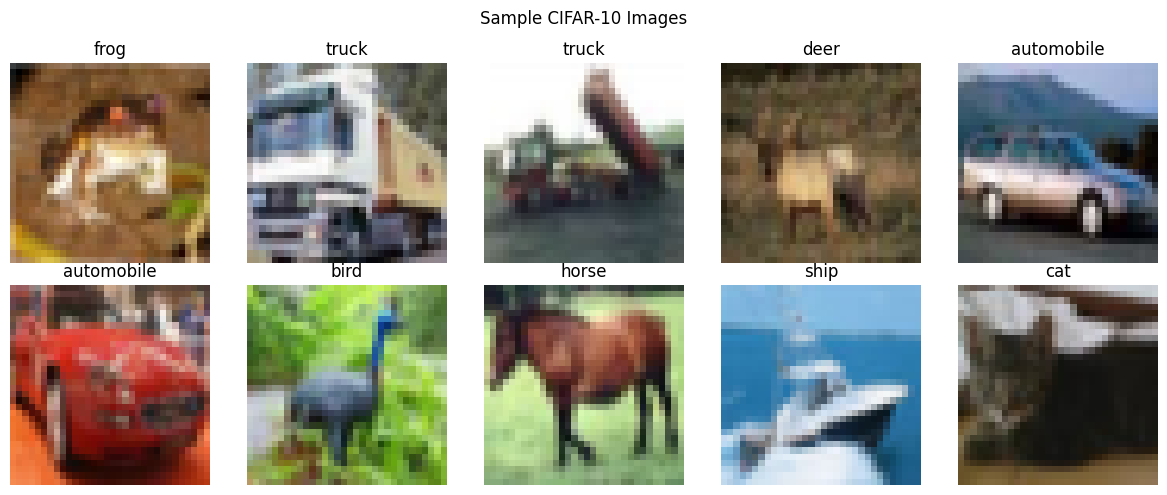

Saved: outputs/sample_images.png


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis('off')

plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.savefig("outputs/sample_images.png")
plt.show()

print("Saved: outputs/sample_images.png")

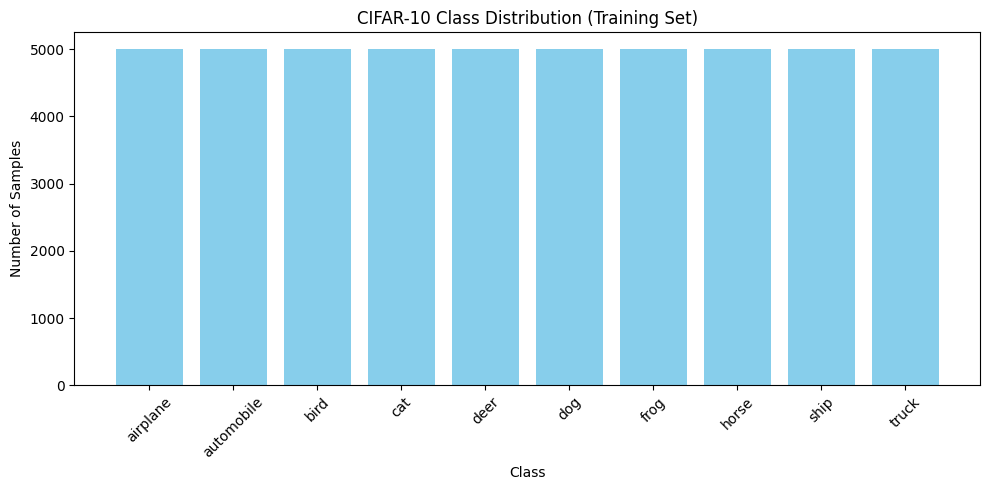

Saved: outputs/class_distribution.png


In [ ]:
labels = [label for _, label in train_dataset]
unique, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar([classes[i] for i in unique], counts, color='skyblue')
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("CIFAR-10 Class Distribution (Training Set)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/class_distribution.png")
plt.show()

print("Saved: outputs/class_distribution.png")

In [ ]:
#TASK 2
class SimpleConvLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super(SimpleConvLayer, self).__init__()
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        )

    def forward(self, x):
        return self.conv(x)

print("SimpleConvLayer class defined successfully.")

SimpleConvLayer class defined successfully.


In [ ]:
sample_img, _ = train_dataset[0]
sample_img = sample_img.unsqueeze(0).to(device)
print("Input image shape:", sample_img.shape)

kernel_sizes = [3, 5, 7]
feature_maps = {}
output_shapes = {}

for k in kernel_sizes:
    conv_layer = SimpleConvLayer(
        in_channels=3, out_channels=8, kernel_size=k, stride=1, padding=0
    ).to(device)

    output = conv_layer(sample_img)
    feature_maps[k] = output
    output_shapes[k] = output.shape

    print(f"Kernel {k}x{k} -> Output feature map shape: {output.shape}")

Input image shape: torch.Size([1, 3, 32, 32])
Kernel 3x3 -> Output feature map shape: torch.Size([1, 8, 30, 30])
Kernel 5x5 -> Output feature map shape: torch.Size([1, 8, 28, 28])
Kernel 7x7 -> Output feature map shape: torch.Size([1, 8, 26, 26])


In [ ]:
print(f"{'Kernel Size':<15}{'Output Shape (C,H,W)':<30}")
print("-" * 45)
for k in kernel_sizes:
    shape = output_shapes[k][1:]
    print(f"{str(k)+'x'+str(k):<15}{str(tuple(shape)):<30}")

Kernel Size    Output Shape (C,H,W)          
---------------------------------------------
3x3            (8, 30, 30)                   
5x5            (8, 28, 28)                   
7x7            (8, 26, 26)                   


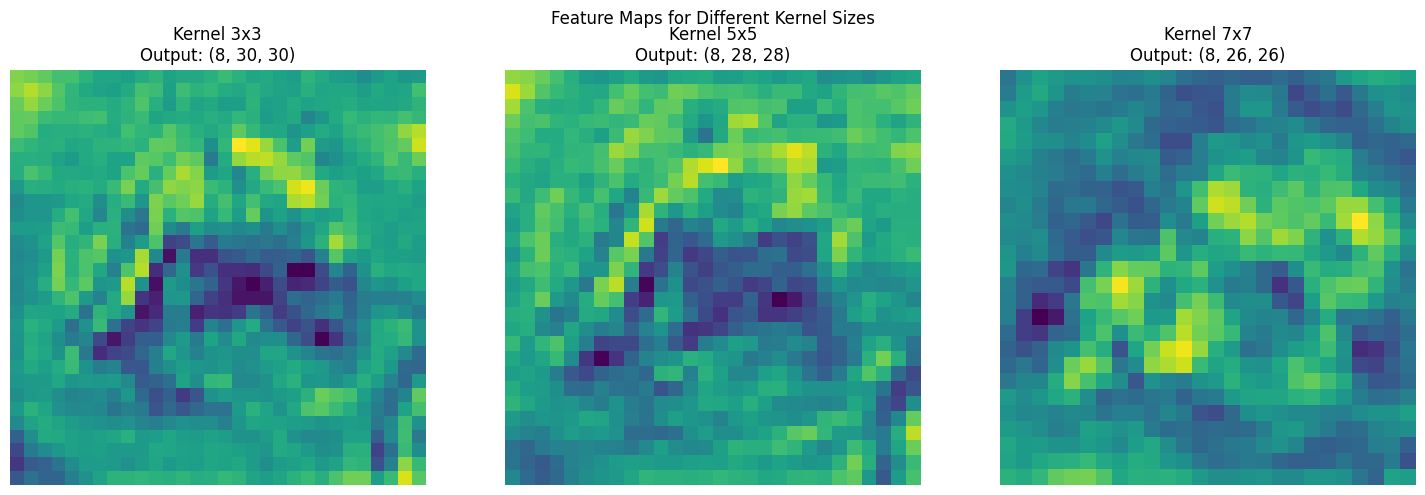

Saved: outputs/feature_maps_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, k in enumerate(kernel_sizes):
    fmap = feature_maps[k][0, 0].detach().cpu().numpy()
    axes[idx].imshow(fmap, cmap='viridis')
    axes[idx].set_title(f"Kernel {k}x{k}\nOutput: {tuple(output_shapes[k][1:])}")
    axes[idx].axis('off')

plt.suptitle("Feature Maps for Different Kernel Sizes")
plt.tight_layout()
plt.savefig("outputs/feature_maps_comparison.png")
plt.show()

print("Saved: outputs/feature_maps_comparison.png")

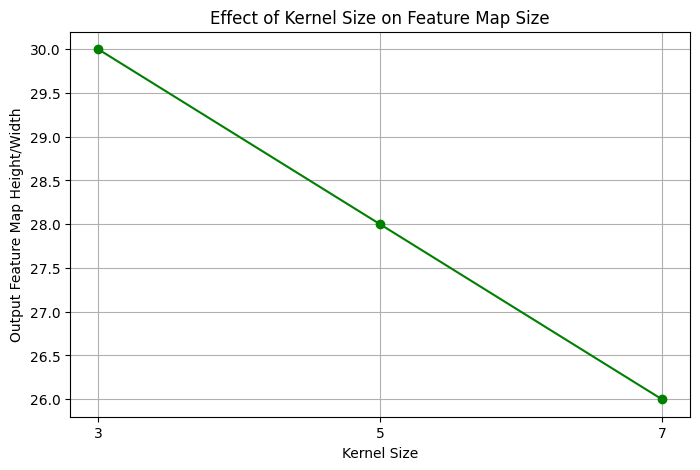

Saved: outputs/kernel_vs_featuremap_size.png


In [ ]:
heights = [output_shapes[k][2] for k in kernel_sizes]

plt.figure(figsize=(8, 5))
plt.plot(kernel_sizes, heights, marker='o', linestyle='-', color='green')
plt.xlabel("Kernel Size")
plt.ylabel("Output Feature Map Height/Width")
plt.title("Effect of Kernel Size on Feature Map Size")
plt.xticks(kernel_sizes)
plt.grid(True)
plt.savefig("outputs/kernel_vs_featuremap_size.png")
plt.show()

print("Saved: outputs/kernel_vs_featuremap_size.png")

In [ ]:
#TASK 4
def conv_output_size(input_size, kernel_size, stride, padding):
    """
    Standard formula:
    Output = floor((Input - Kernel + 2*Padding) / Stride) + 1
    """
    return ((input_size - kernel_size + 2 * padding) // stride) + 1

print("Example: input=32, kernel=3, stride=1, padding=0 ->",
      conv_output_size(32, 3, 1, 0))

Example: input=32, kernel=3, stride=1, padding=0 -> 30


In [ ]:
input_size = 32
kernel_size = 3
padding = 1

strides = [1, 2]
stride_results = {}

for s in strides:
    conv_layer = SimpleConvLayer(
        in_channels=3, out_channels=8, kernel_size=kernel_size,
        stride=s, padding=padding
    ).to(device)

    output = conv_layer(sample_img)
    stride_results[s] = output.shape
    computed = conv_output_size(input_size, kernel_size, s, padding)

    print(f"Stride={s} -> Output shape: {output.shape} | Formula check: {computed}x{computed}")

Stride=1 -> Output shape: torch.Size([1, 8, 32, 32]) | Formula check: 32x32
Stride=2 -> Output shape: torch.Size([1, 8, 16, 16]) | Formula check: 16x16


In [ ]:
padding_modes = ['same', 'valid']
padding_results = {}

for p in padding_modes:
    conv_layer = nn.Conv2d(
        in_channels=3, out_channels=8, kernel_size=3,
        stride=1, padding=p
    ).to(device)

    output = conv_layer(sample_img)
    padding_results[p] = output.shape
    print(f"Padding='{p}' -> Output shape: {output.shape}")

Padding='same' -> Output shape: torch.Size([1, 8, 32, 32])
Padding='valid' -> Output shape: torch.Size([1, 8, 30, 30])


In [ ]:
print("STRIDE COMPARISON (kernel=3x3, padding=1)")
print(f"{'Stride':<10}{'Output Shape (C,H,W)':<25}")
print("-" * 35)
for s in strides:
    shape = stride_results[s][1:]
    print(f"{s:<10}{str(tuple(shape)):<25}")

print("\nPADDING COMPARISON (kernel=3x3, stride=1)")
print(f"{'Padding':<10}{'Output Shape (C,H,W)':<25}")
print("-" * 35)
for p in padding_modes:
    shape = padding_results[p][1:]
    print(f"{p:<10}{str(tuple(shape)):<25}")

STRIDE COMPARISON (kernel=3x3, padding=1)
Stride    Output Shape (C,H,W)     
-----------------------------------
1         (8, 32, 32)              
2         (8, 16, 16)              

PADDING COMPARISON (kernel=3x3, stride=1)
Padding   Output Shape (C,H,W)     
-----------------------------------
same      (8, 32, 32)              
valid     (8, 30, 30)              


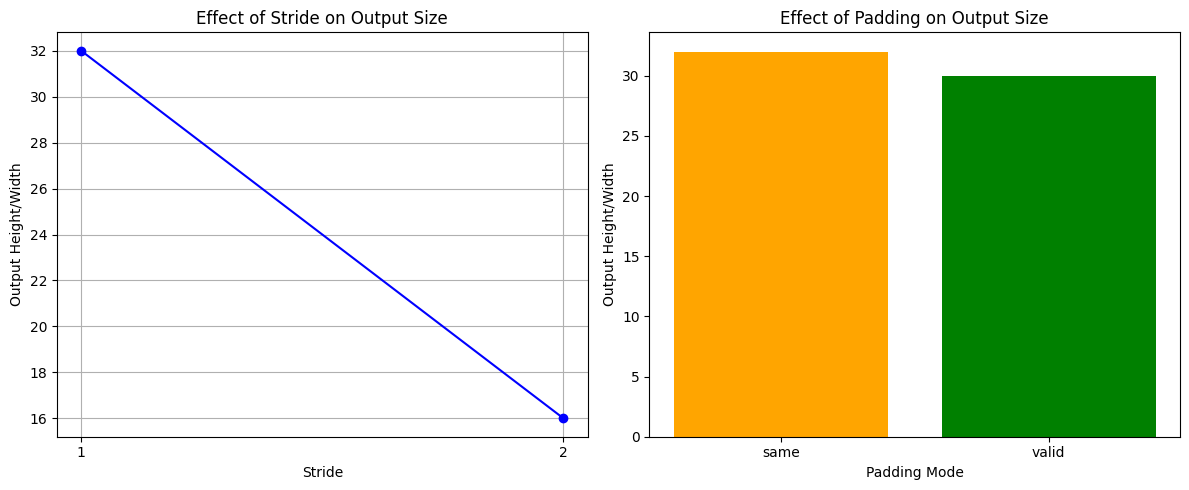

Saved: outputs/stride_padding_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stride plot
stride_heights = [stride_results[s][2] for s in strides]
axes[0].plot(strides, stride_heights, marker='o', color='blue')
axes[0].set_title("Effect of Stride on Output Size")
axes[0].set_xlabel("Stride")
axes[0].set_ylabel("Output Height/Width")
axes[0].set_xticks(strides)
axes[0].grid(True)

# Padding plot
padding_heights = [padding_results[p][2] for p in padding_modes]
axes[1].bar(padding_modes, padding_heights, color=['orange', 'green'])
axes[1].set_title("Effect of Padding on Output Size")
axes[1].set_xlabel("Padding Mode")
axes[1].set_ylabel("Output Height/Width")

plt.tight_layout()
plt.savefig("outputs/stride_padding_comparison.png")
plt.show()

print("Saved: outputs/stride_padding_comparison.png")

In [ ]:
#TASK 4
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
)


In [ ]:
model.eval()
with torch.no_grad():
    first_layer_output = model(sample_img)

print("First conv layer output shape:", first_layer_output.shape)

First conv layer output shape: torch.Size([1, 16, 32, 32])


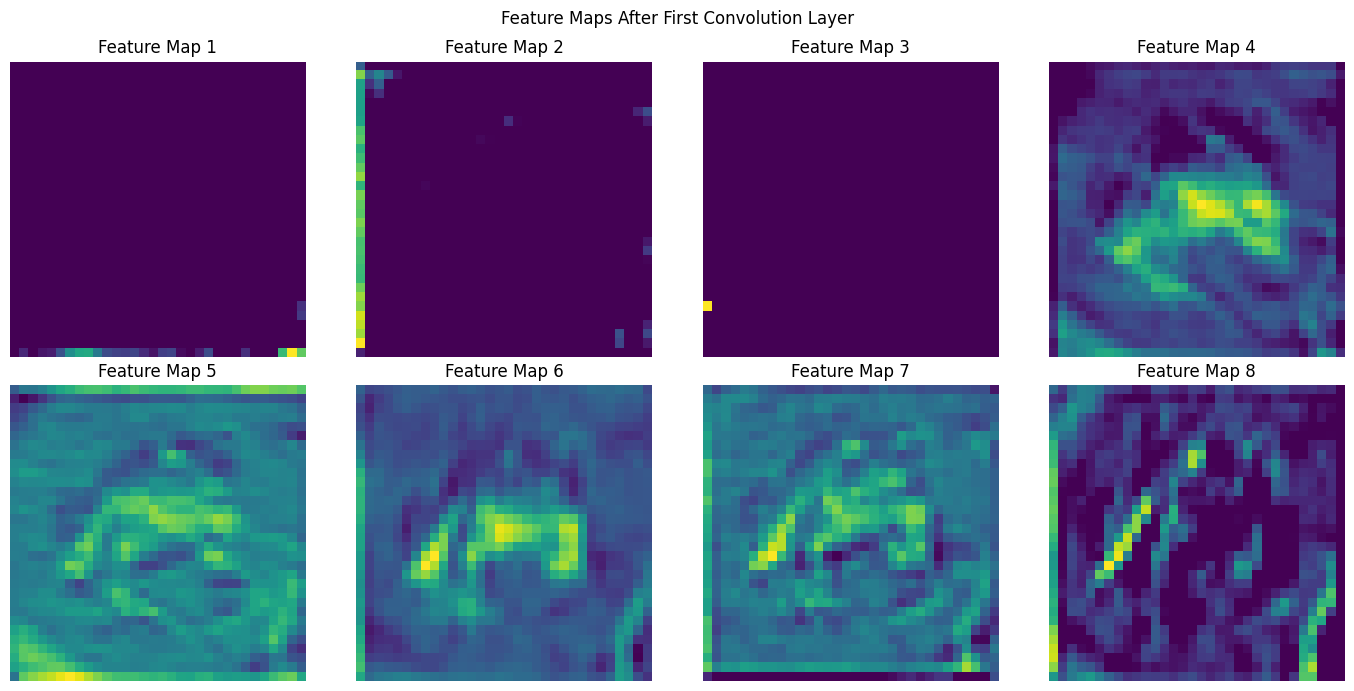

Saved: outputs/first_layer_feature_maps.png


In [ ]:
num_maps_to_show = 8

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.flat):
    if i < num_maps_to_show:
        fmap = first_layer_output[0, i].detach().cpu().numpy()
        ax.imshow(fmap, cmap='viridis')
        ax.set_title(f"Feature Map {i+1}")
        ax.axis('off')

plt.suptitle("Feature Maps After First Convolution Layer")
plt.tight_layout()
plt.savefig("outputs/first_layer_feature_maps.png")
plt.show()

print("Saved: outputs/first_layer_feature_maps.png")

In [ ]:
#TASK 5
maxpool_layer = nn.MaxPool2d(kernel_size=2, stride=2)
avgpool_layer = nn.AvgPool2d(kernel_size=2, stride=2)

maxpool_output = maxpool_layer(first_layer_output)
avgpool_output = avgpool_layer(first_layer_output)

print("Input to pooling shape:", first_layer_output.shape)
print("MaxPool output shape:", maxpool_output.shape)
print("AvgPool output shape:", avgpool_output.shape)

Input to pooling shape: torch.Size([1, 16, 32, 32])
MaxPool output shape: torch.Size([1, 16, 16, 16])
AvgPool output shape: torch.Size([1, 16, 16, 16])


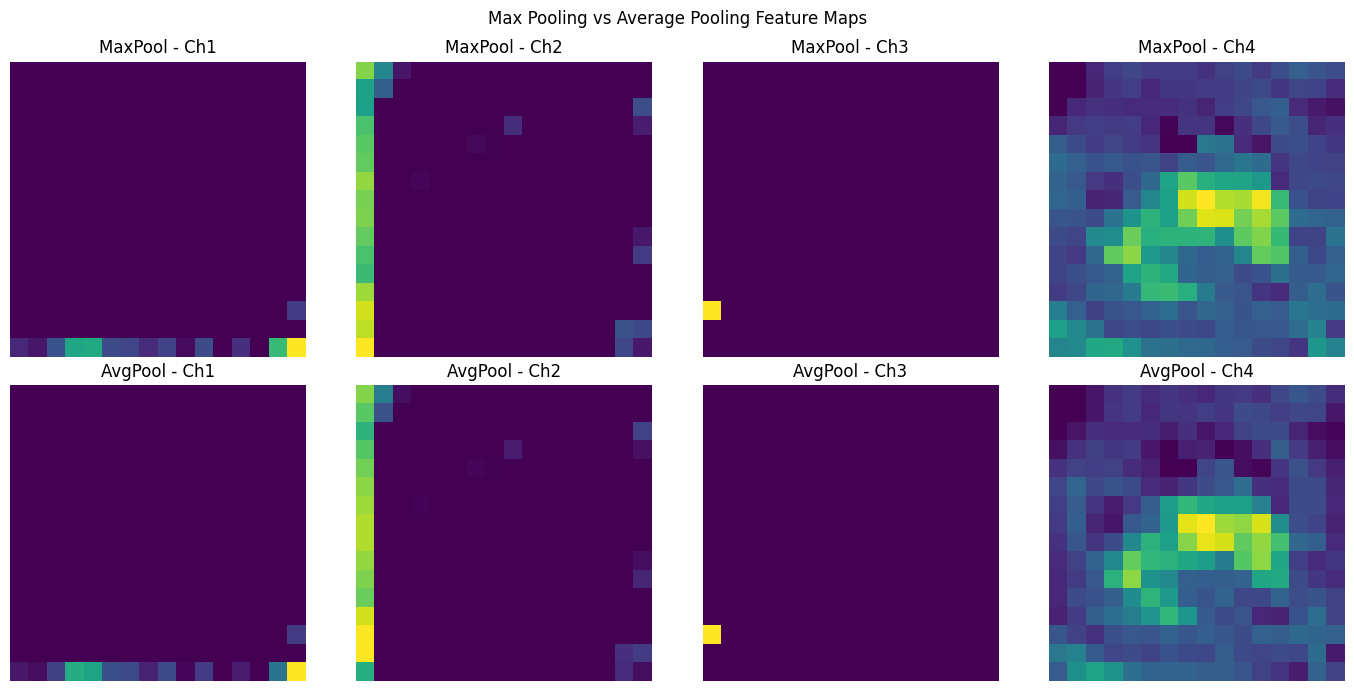

Saved: outputs/maxpool_vs_avgpool_featuremaps.png


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i in range(4):
    fmap_max = maxpool_output[0, i].detach().cpu().numpy()
    axes[0, i].imshow(fmap_max, cmap='viridis')
    axes[0, i].set_title(f"MaxPool - Ch{i+1}")
    axes[0, i].axis('off')

    fmap_avg = avgpool_output[0, i].detach().cpu().numpy()
    axes[1, i].imshow(fmap_avg, cmap='viridis')
    axes[1, i].set_title(f"AvgPool - Ch{i+1}")
    axes[1, i].axis('off')

plt.suptitle("Max Pooling vs Average Pooling Feature Maps")
plt.tight_layout()
plt.savefig("outputs/maxpool_vs_avgpool_featuremaps.png")
plt.show()

print("Saved: outputs/maxpool_vs_avgpool_featuremaps.png")

In [ ]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 1563
Number of test batches: 313


In [ ]:
class PoolCompareCNN(nn.Module):
    def __init__(self, pool_type='max'):
        super(PoolCompareCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        if pool_type == 'max':
            self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        elif pool_type == 'avg':
            self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(16 * 16 * 16, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

print("PoolCompareCNN class defined.")

PoolCompareCNN class defined.


In [ ]:
def train_and_evaluate(pool_type, epochs=5):
    model = PoolCompareCNN(pool_type=pool_type).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"[{pool_type}] Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

    # Evaluate
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

max_acc = train_and_evaluate('max', epochs=5)
avg_acc = train_and_evaluate('avg', epochs=5)

print(f"\nMax Pooling Test Accuracy: {max_acc:.2f}%")
print(f"Average Pooling Test Accuracy: {avg_acc:.2f}%")

[max] Epoch 1/5 - Loss: 1.1157
[max] Epoch 2/5 - Loss: 1.6713
[max] Epoch 3/5 - Loss: 0.7020
[max] Epoch 4/5 - Loss: 1.4984
[max] Epoch 5/5 - Loss: 0.8457
[avg] Epoch 1/5 - Loss: 1.0864
[avg] Epoch 2/5 - Loss: 1.1307
[avg] Epoch 3/5 - Loss: 1.4471
[avg] Epoch 4/5 - Loss: 1.1643
[avg] Epoch 5/5 - Loss: 0.7841

Max Pooling Test Accuracy: 58.68%
Average Pooling Test Accuracy: 54.62%


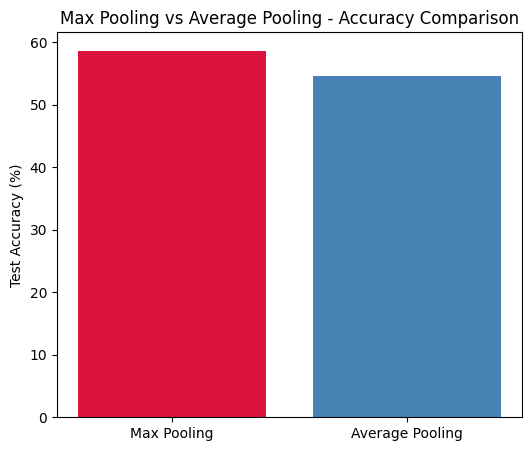

Saved: outputs/pooling_accuracy_comparison.png


In [ ]:
plt.figure(figsize=(6, 5))
plt.bar(['Max Pooling', 'Average Pooling'], [max_acc, avg_acc], color=['crimson', 'steelblue'])
plt.ylabel("Test Accuracy (%)")
plt.title("Max Pooling vs Average Pooling - Accuracy Comparison")
plt.savefig("outputs/pooling_accuracy_comparison.png")
plt.show()

print("Saved: outputs/pooling_accuracy_comparison.png")

In [ ]:
#TASK 6
class FullCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(FullCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.fc(x)
        return x

final_model = FullCNN(num_classes=10).to(device)
print(final_model)

FullCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=4096, out_features=10, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=0.001)

num_epochs = 20

train_losses = []
train_accuracies = []
test_accuracies = []

In [ ]:
for epoch in range(num_epochs):
    final_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = final_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total

    final_model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = final_model(images)
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
    epoch_test_acc = 100 * correct_test / total_test

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_train_acc)
    test_accuracies.append(epoch_test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_train_acc:.2f}% | "
          f"Test Acc: {epoch_test_acc:.2f}%")

Epoch [1/20] Loss: 1.4481 | Train Acc: 48.70% | Test Acc: 57.20%
Epoch [2/20] Loss: 1.1214 | Train Acc: 60.82% | Test Acc: 62.82%
Epoch [3/20] Loss: 0.9928 | Train Acc: 65.67% | Test Acc: 65.55%
Epoch [4/20] Loss: 0.9075 | Train Acc: 68.62% | Test Acc: 67.52%
Epoch [5/20] Loss: 0.8457 | Train Acc: 70.67% | Test Acc: 68.55%
Epoch [6/20] Loss: 0.7982 | Train Acc: 72.41% | Test Acc: 68.73%
Epoch [7/20] Loss: 0.7595 | Train Acc: 73.65% | Test Acc: 69.78%
Epoch [8/20] Loss: 0.7207 | Train Acc: 75.04% | Test Acc: 69.62%
Epoch [9/20] Loss: 0.6980 | Train Acc: 75.72% | Test Acc: 70.16%
Epoch [10/20] Loss: 0.6659 | Train Acc: 76.92% | Test Acc: 69.21%
Epoch [11/20] Loss: 0.6470 | Train Acc: 77.39% | Test Acc: 70.44%
Epoch [12/20] Loss: 0.6241 | Train Acc: 78.24% | Test Acc: 69.42%
Epoch [13/20] Loss: 0.6014 | Train Acc: 79.07% | Test Acc: 70.66%
Epoch [14/20] Loss: 0.5846 | Train Acc: 79.54% | Test Acc: 69.92%
Epoch [15/20] Loss: 0.5664 | Train Acc: 80.32% | Test Acc: 69.82%
Epoch [16/20] Loss:

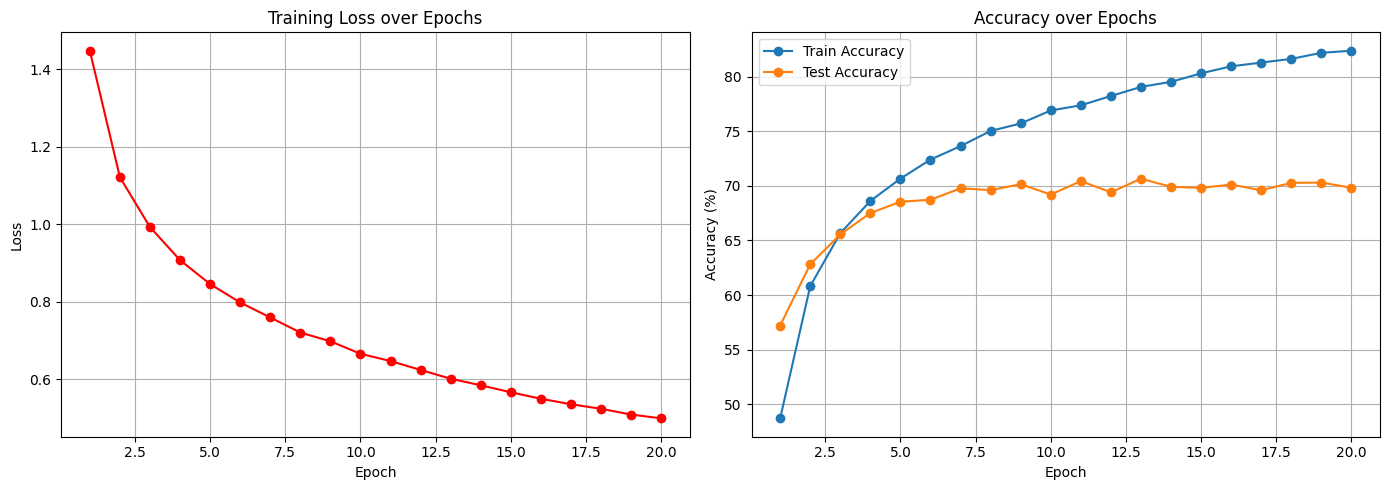

Saved: outputs/training_curves.png

Final Test Accuracy after 20 epochs: 69.83%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, num_epochs+1), train_losses, marker='o', color='red')
axes[0].set_title("Training Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(range(1, num_epochs+1), train_accuracies, marker='o', label='Train Accuracy')
axes[1].plot(range(1, num_epochs+1), test_accuracies, marker='o', label='Test Accuracy')
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("outputs/training_curves.png")
plt.show()

print("Saved: outputs/training_curves.png")
print(f"\nFinal Test Accuracy after {num_epochs} epochs: {test_accuracies[-1]:.2f}%")

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import seaborn as sns

In [ ]:
final_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Total test predictions collected:", len(all_preds))

Total test predictions collected: 10000


In [ ]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1-score  : {f1*100:.2f}%")

Accuracy  : 69.83%
Precision : 70.28%
Recall    : 69.83%
F1-score  : 69.84%


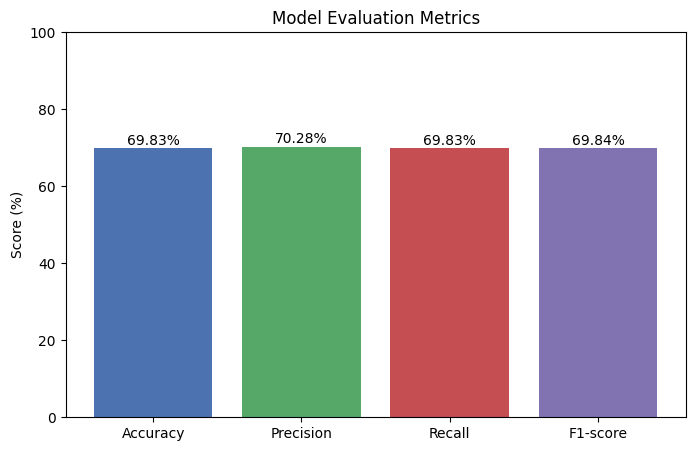

Saved: outputs/evaluation_metrics_summary.png


In [ ]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
metrics_values = [accuracy*100, precision*100, recall*100, f1*100]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_names, metrics_values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.ylabel("Score (%)")
plt.title("Model Evaluation Metrics")
plt.ylim(0, 100)

for bar, val in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.2f}%", ha='center')

plt.savefig("outputs/evaluation_metrics_summary.png")
plt.show()

print("Saved: outputs/evaluation_metrics_summary.png")

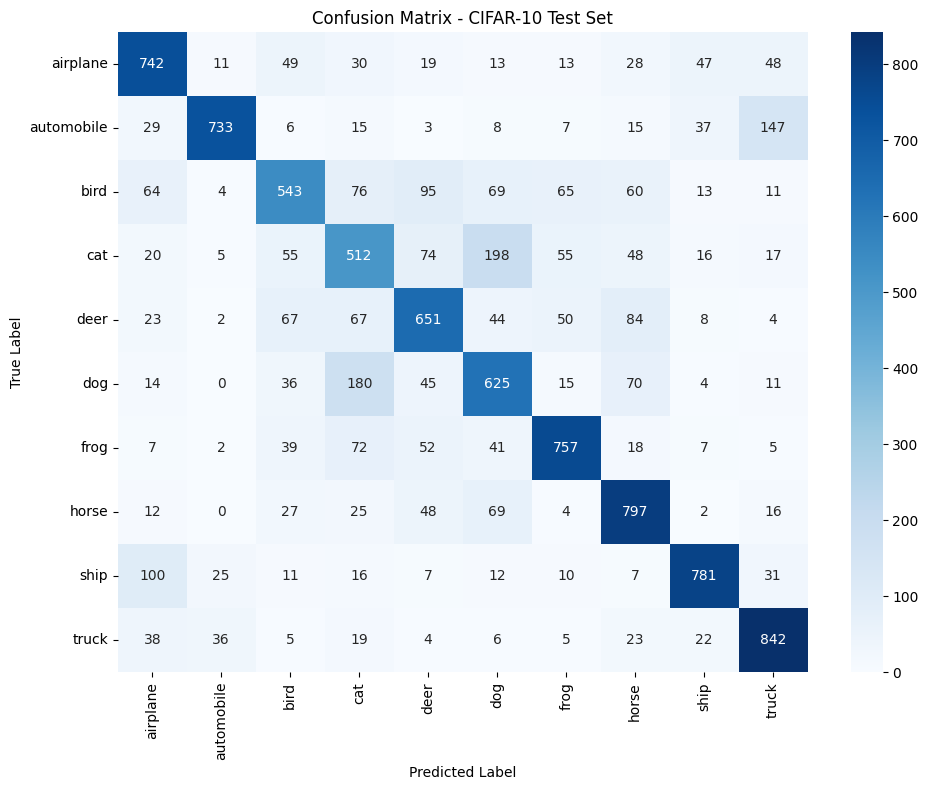

Saved: outputs/confusion_matrix.png


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CIFAR-10 Test Set")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png")
plt.show()

print("Saved: outputs/confusion_matrix.png")

In [ ]:
report = classification_report(all_labels, all_preds, target_names=classes)
print("Classification Report:\n")
print(report)

with open("outputs/classification_report.txt", "w") as f:
    f.write(report)

print("\nSaved: outputs/classification_report.txt")

Classification Report:

              precision    recall  f1-score   support

    airplane       0.71      0.74      0.72      1000
  automobile       0.90      0.73      0.81      1000
        bird       0.65      0.54      0.59      1000
         cat       0.51      0.51      0.51      1000
        deer       0.65      0.65      0.65      1000
         dog       0.58      0.62      0.60      1000
        frog       0.77      0.76      0.76      1000
       horse       0.69      0.80      0.74      1000
        ship       0.83      0.78      0.81      1000
       truck       0.74      0.84      0.79      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000


Saved: outputs/classification_report.txt


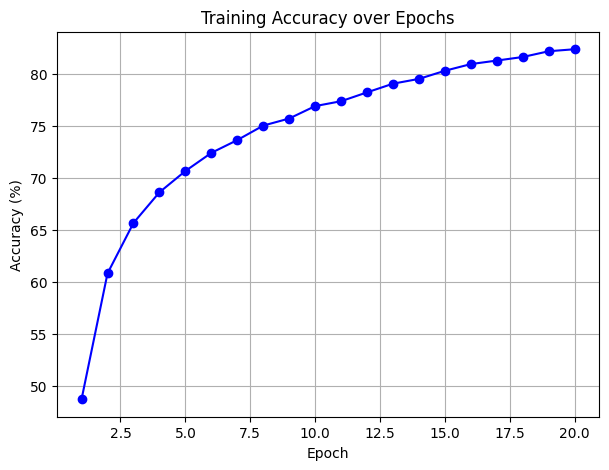

Saved: outputs/training_accuracy.png


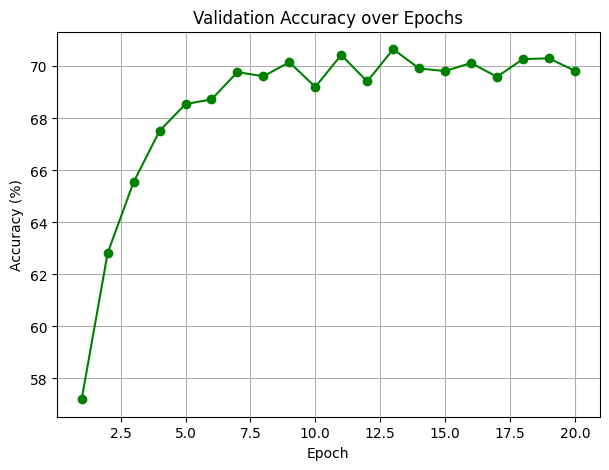

Saved: outputs/validation_accuracy.png


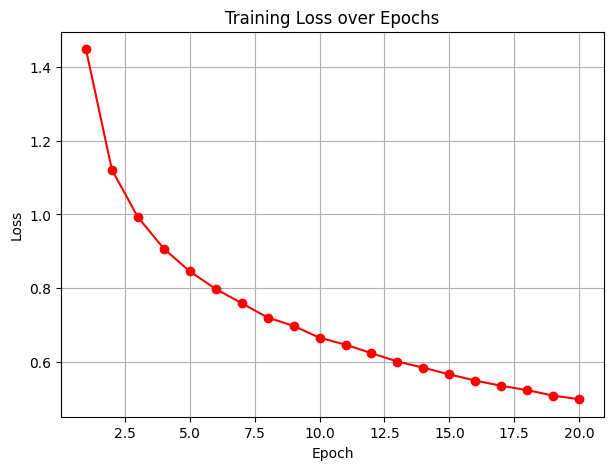

Saved: outputs/training_loss.png


In [ ]:
epochs_range = range(1, num_epochs + 1)

# 3. Training Accuracy
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, train_accuracies, marker='o', color='blue')
plt.title("Training Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.savefig("outputs/training_accuracy.png")
plt.show()
print("Saved: outputs/training_accuracy.png")

# 4. Validation Accuracy (using your existing test_accuracies list)
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, test_accuracies, marker='o', color='green')
plt.title("Validation Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.savefig("outputs/validation_accuracy.png")
plt.show()
print("Saved: outputs/validation_accuracy.png")

# 5. Training Loss
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, train_losses, marker='o', color='red')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("outputs/training_loss.png")
plt.show()
print("Saved: outputs/training_loss.png")

Trained model's first conv layer output shape: torch.Size([1, 32, 32, 32])


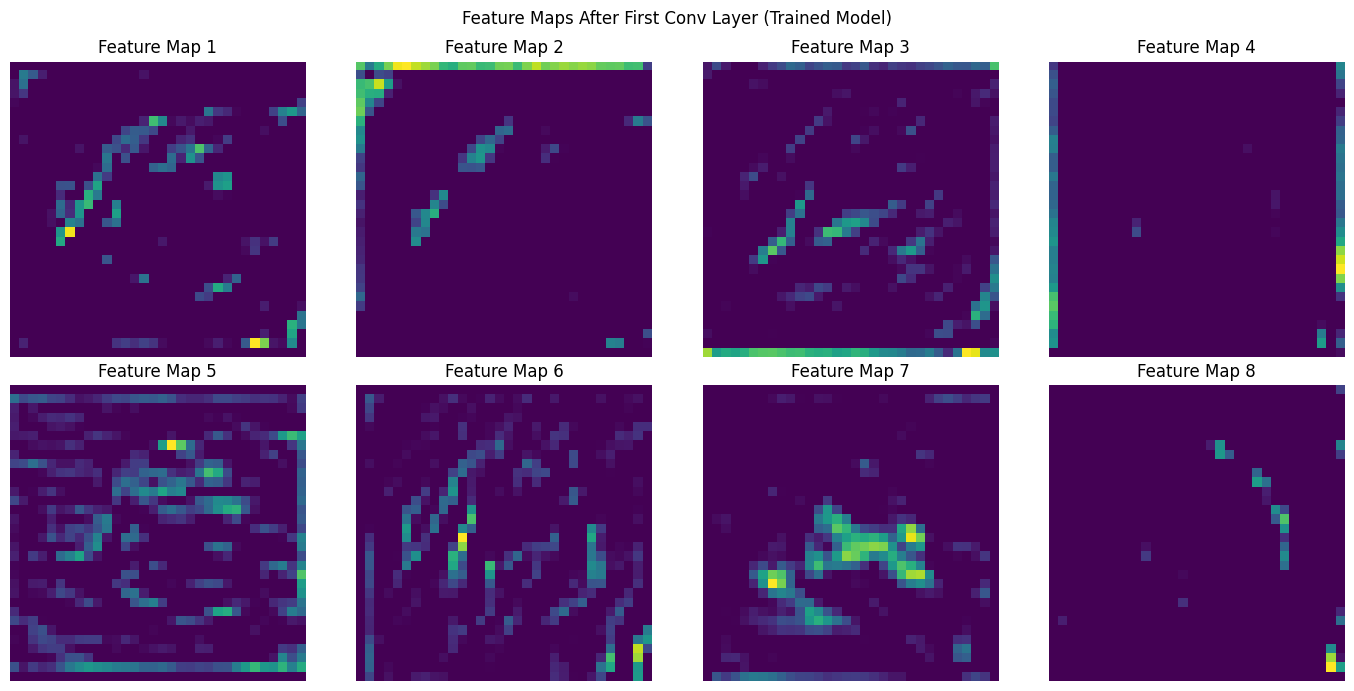

Saved: outputs/feature_maps_trained_model.png


In [ ]:
final_model.eval()
with torch.no_grad():
    conv1_output = final_model.relu1(final_model.conv1(sample_img))

print("Trained model's first conv layer output shape:", conv1_output.shape)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    fmap = conv1_output[0, i].detach().cpu().numpy()
    ax.imshow(fmap, cmap='viridis')
    ax.set_title(f"Feature Map {i+1}")
    ax.axis('off')

plt.suptitle("Feature Maps After First Conv Layer (Trained Model)")
plt.tight_layout()
plt.savefig("outputs/feature_maps_trained_model.png")
plt.show()

print("Saved: outputs/feature_maps_trained_model.png")

In [ ]:
final_model.eval()
val_loss_total = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model(images)
        loss = criterion(outputs, labels)
        val_loss_total += loss.item()

final_val_loss = val_loss_total / len(test_loader)
print(f"Final Validation Loss (on trained model): {final_val_loss:.4f}")

Final Validation Loss (on trained model): 0.9963
